<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/notebooks/02_modeling_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Machine Learning Final Project
# Predicting Annual Wine Production by Viticultural Region in Portugal

In this section, we prepare the data for the first predictive model. The target is annual wine production, and the predictors are region, campaign year, and vineyard area. Missing values in vineyard area will be handled inside the modeling pipeline.

In [26]:
# prompt:Set up a project directory structure for saving figures and tables in a machine learning project.

from pathlib import Path

FIGURES_DIR = Path("outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TABLES_DIR = Path("outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [27]:
# prompt: Import essential libraries for building a machine learning regression pipeline, including data manipulation, preprocessing, model training, and evaluation tools.

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [28]:
# prompt: Load cleaned wine production and vineyard area datasets from a GitHub repository and merge them by region and year to create a modeling dataset.

from pathlib import Path
import pandas as pd

# GitHub raw base URL
BASE_URL = "https://raw.githubusercontent.com/oxedanda/pml_final_project/main/data/processed"

PRODUCTION_FILE = f"{BASE_URL}/wine_production_by_region_clean.csv"
AREA_FILE = f"{BASE_URL}/vineyard_area_by_region_clean.csv"

# Load datasets directly from GitHub
production = pd.read_csv(PRODUCTION_FILE)
area = pd.read_csv(AREA_FILE)

# Merge datasets
df = production.merge(
    area,
    on=["region", "year_start"],
    how="left"
)

print("Production shape:", production.shape)
print("Area shape:", area.shape)
print("Merged shape:", df.shape)

display(df.head())

Production shape: (238, 8)
Area shape: (288, 3)
Merged shape: (238, 9)


,region,campaign_year,year_start,total_production_hl,dop_production_hl,igp_production_hl,year_variety_production_hl,non_certified_production_hl,vineyard_area_ha
0,Alentejo,2009/10,2009,810338,356783,449833,995,2728,23490.0
1,Algarve,2009/10,2009,23650,4680,11797,0,7173,1983.0
2,Açores,2009/10,2009,13754,2771,2832,6,8145,1700.0
3,Bairrada,2009/10,2009,246705,69459,64138,1068,112041,NaN
4,Beira Interior,2009/10,2009,192084,50158,20570,14,121342,NaN


In [29]:
# prompt: Define target variable and select feature set for a regression model predicting annual wine production using region, year, and vineyard area as predictors.

# Target variable

target = "total_production_hl"

feature_columns = [
    "region",
    "year_start",
    "vineyard_area_ha",
]

X = df[feature_columns].copy()
y = df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (238, 3)
Target shape: (238,)


,region,year_start,vineyard_area_ha
0,Alentejo,2009,23490.0
1,Algarve,2009,1983.0
2,Açores,2009,1700.0
3,Bairrada,2009,NaN
4,Beira Interior,2009,NaN


,total_production_hl
0,810338
1,23650
2,13754
3,246705
4,192084


In [30]:
# prompt: Inspect missing values and data types in the feature set to assess data quality before applying machine learning preprocessing steps.

# Check missing values in the modeling features

print("Missing values in features:")
display(X.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nFeature types:")
display(X.dtypes.to_frame("dtype"))

Missing values in features:


,missing_count
vineyard_area_ha,38
region,0
year_start,0



Feature types:


,dtype
region,object
year_start,int64
vineyard_area_ha,float64


In [31]:
# prompt: Perform a chronological train-test split to preserve temporal structure in a regression problem, using the most recent campaign years as the test set. Then define a preprocessing pipeline with imputation and one-hot encoding, and build a baseline linear regression model.

# Chronological Split and Preprocessing Pipeline

# Sort by time to respect temporal structure
df_sorted = df.sort_values(["year_start", "region"]).reset_index(drop=True)

# Define target and features
X = df_sorted[feature_columns].copy()
y = df_sorted[target].copy()

# Use the last 3 campaign years as test set
test_years = sorted(df_sorted["year_start"].unique())[-3:]

train_data = df_sorted[~df_sorted["year_start"].isin(test_years)].copy()
test_data = df_sorted[df_sorted["year_start"].isin(test_years)].copy()

X_train = train_data[feature_columns]
y_train = train_data[target]
X_test = test_data[feature_columns]
y_test = test_data[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Test years:", test_years)

# Preprocessing
numeric_features = ["year_start", "vineyard_area_ha"]
categorical_features = ["region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Baseline model
model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression()),
    ]
)

Train shape: (196, 3)
Test shape: (42, 3)
Test years: [np.int64(2023), np.int64(2024), np.int64(2025)]


## Model Evaluation

The baseline model was evaluated on the most recent campaign years to respect the temporal structure of the problem. The main metrics used were MAE, RMSE, and R².

In [32]:
# prompt: Train a baseline regression model using a preprocessing pipeline and evaluate its performance on a temporally held-out test set using MAE, RMSE, and R² metrics.

# Train the Model and Evaluate

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

# Save metrics for report
metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

display(metrics)

metrics.to_csv(
    TABLES_DIR / "model_metrics.csv",
    index=False
)

MAE: 80,649.69
RMSE: 116,422.76
R²: 0.9464


,metric,value
0,MAE,80649.687213
1,RMSE,116422.760819
2,R2,0.946353


In [33]:
# prompt: Create a results dataframe containing actual and predicted values from a regression model along with prediction errors for evaluation analysis.

# Create Results Table for Model Evaluation

results = X_test.copy().reset_index(drop=True)

results["actual"] = y_test.values
results["predicted"] = y_pred
results["error"] = results["actual"] - results["predicted"]

display(results.head(10))

# Save results table for report
results.to_csv(
    TABLES_DIR / "model_predictions_results.csv",
    index=False
)

,region,year_start,vineyard_area_ha,actual,predicted,error
0,Alentejo,2023,26443.0,1233148,1.104641e+06,128506.583827
1,Algarve,2023,1355.0,16613,4.204705e+04,-25434.046050
2,Açores,2023,1737.0,8007,3.564560e+04,-27638.595145
3,Bairrada,2023,9440.0,251051,2.613120e+05,-10260.981730
4,Beira Interior,2023,11738.0,185805,2.451646e+05,-59359.630263
5,Douro,2023,44224.0,1561729,1.465986e+06,95743.086973
6,Dão,2023,12898.0,281210,3.085657e+05,-27355.689103
7,Lisboa,2023,17857.0,1539151,1.119030e+06,420121.079571
8,Madeira,2023,669.0,37800,6.767213e+04,-29872.125651
9,P. Setúbal,2023,7417.0,589897,4.948691e+05,95027.943714


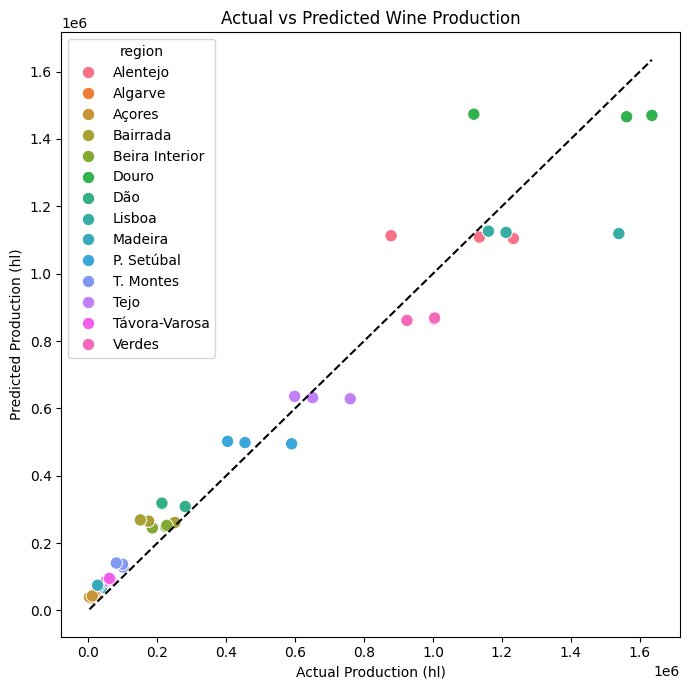

In [34]:
# prompt: Create an actual vs predicted scatter plot to visually evaluate regression model performance across regions, including a reference diagonal line for perfect predictions.

# Actual vs Predicted Plot
import matplotlib.pyplot as plt
import seaborn as sns

results = X_test.copy().reset_index(drop=True)
results["actual"] = y_test.values
results["predicted"] = y_pred
results["error"] = results["actual"] - results["predicted"]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=results, x="actual", y="predicted", hue="region", s=80)

min_val = min(results["actual"].min(), results["predicted"].min())
max_val = max(results["actual"].max(), results["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")

plt.title("Actual vs Predicted Wine Production")
plt.xlabel("Actual Production (hl)")
plt.ylabel("Predicted Production (hl)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "actual_vs_predicted_wine_production.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The actual vs predicted plot compares model predictions with observed values of wine production. Points located closer to the diagonal reference line indicate lower prediction error, while points further from the line correspond to larger deviations between predicted and actual values. The distribution of points provides a visual assessment of model performance across regions and production levels.

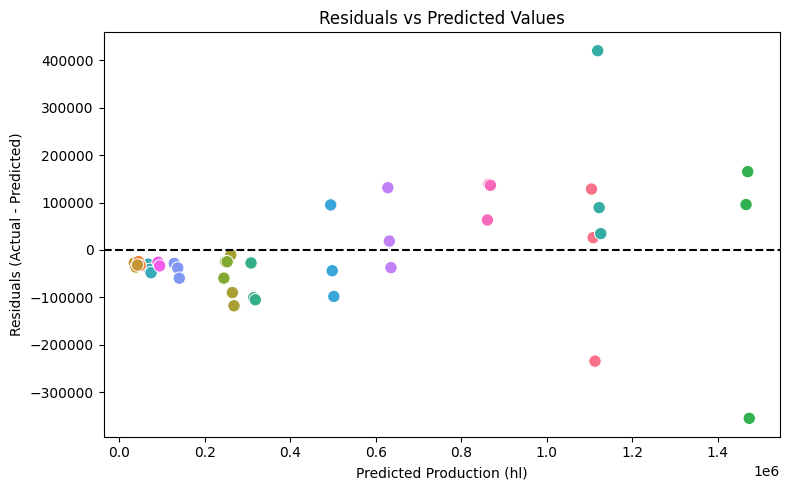

In [35]:
# prompt: Create a residuals vs predicted values plot to evaluate error patterns and check whether residuals are randomly distributed around zero across regions.

# Residual Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent evaluation dataframe
results = X_test.copy().reset_index(drop=True)
results["actual"] = y_test.values
results["predicted"] = y_pred
results["error"] = results["actual"] - results["predicted"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=results,
    x="predicted",
    y="error",
    hue="region",
    s=80,
    legend=False
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Production (hl)")
plt.ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "residuals_vs_predicted_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The residual plot shows the distribution of prediction errors relative to the predicted values. If residuals are randomly distributed around zero, this indicates that the model captures the main structure of the data without systematic bias. In contrast, the presence of visible patterns or structured deviations may suggest that relevant explanatory variables are missing or that a more flexible modeling approach is required.

## Results Interpretation and Evaluation Summary

The baseline linear regression model is evaluated on a temporally held-out test set, using MAE, RMSE, and R² as performance metrics. The model achieves an R² of 0.9464, indicating that a large proportion of the variance in annual wine production is explained by the selected predictors (region, year, and vineyard area).

The error metrics show a MAE of approximately 80,650 hectoliters and an RMSE of 116,423 hectoliters. The difference between MAE and RMSE suggests the presence of higher-magnitude errors in a subset of observations, which have a stronger influence on RMSE.

Residual analysis indicates variability in prediction errors across regions and years, suggesting that the model does not fully capture all sources of variation in wine production. Factors not included in the dataset, such as climatic conditions, disease pressure, and management practices, may contribute to this unexplained variation.

Overall, the model serves as a baseline benchmark for predicting annual wine production. It demonstrates that the selected predictors capture most of the structural variation in the data, while also highlighting clear opportunities for improvement through additional features and more flexible modeling approaches.

## Final Conclusion

This notebook develops a baseline regression model for predicting annual wine production by region in Portugal. The results indicate that region, year, and vineyard area are strong predictors of production, but additional variables are likely required to further improve predictive performance.